In [69]:
# Xử lý dữ liệu
import numpy as np
import pandas as pd

# Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Chia dữ liệu
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Các mô hình
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
# Đánh giá
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [70]:
# Đường dẫn dữ liệu
DATA_PATH = "pima-indians-diabetes.csv"
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]
# Tỉ lệ chia train/test
TEST_SIZE = 0.2

# Đảm bảo kết quả không bị random mỗi lần chạy
RANDOM_STATE = 42

# Tham số cho model
K = 5  # cho KNN
MAX_DEPTH = 5  # cho Decision Tree

In [71]:
df = pd.read_csv(DATA_PATH, names = columns)

#Xem nhanh dữ liệu
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [72]:
X = df.drop("Outcome", axis=1) # đặc trưng
y = df["Outcome"] #nhãn

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Chia dữ liệu theo hold-out

In [74]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size = 0.3, # 30% test
    random_state=42
)

In [75]:
# chia lần 2: train + validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size = 0.3, #30% của train -> validation
    random_state=42
)

In [76]:
model = DecisionTreeClassifier()

scores = cross_val_score(model, X, y, cv=5)

print("Accuracy từng fold:", scores)
print("Trung bình:", scores.mean())

Accuracy từng fold: [0.66233766 0.65584416 0.68831169 0.79084967 0.71895425]
Trung bình: 0.7032594856124268


In [77]:
# Danh sách mô hình
models = []
models.append(("LR", LogisticRegression()))
models.append(("LDA", LinearDiscriminantAnalysis()))
models.append(("KNN", KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB", GaussianNB()))
models.append(("SVM", SVC()))

In [78]:
# Đánh giá bằng k-fold
results = []
names = []

for name, model in models:
    kfold = KFold(n_splits=10, random_state=42, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")
    
    results.append(cv_results)
    names.append(name)
    
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also re

LR: 0.7706 (0.0768)
LDA: 0.7732 (0.0715)
KNN: 0.7334 (0.0424)
CART: 0.6962 (0.0561)
NB: 0.7651 (0.0676)
SVM: 0.7731 (0.0504)


In [79]:
param_grid = {
    "n_neighbors": [3,5,7,9,11]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best score:", grid.best_score_)

Best K: {'n_neighbors': 11}
Best score: 0.7546666666666667


In [80]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'C': 10, 'kernel': 'rbf'}
Best score: 0.7813333333333332


In [81]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.7402597402597403


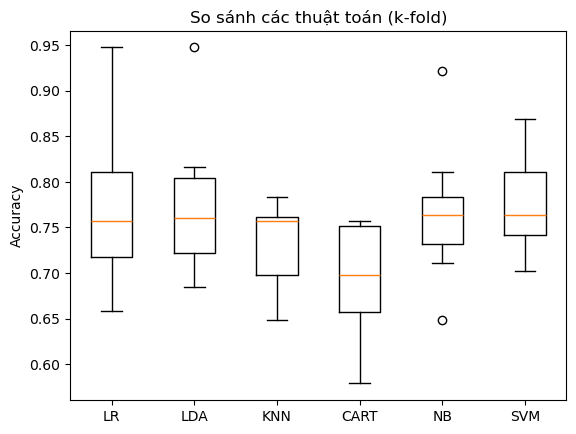

In [82]:
plt.figure()

plt.boxplot(results)
plt.xticks(range(1, len(names)+1), names)

plt.title("So sánh các thuật toán (k-fold)")
plt.ylabel("Accuracy")

plt.show()

In [83]:
baseline_model = LogisticRegression()
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [84]:
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))
print(confusion_matrix(y_test, y_pred_base))

Baseline Accuracy: 0.7575757575757576
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       151
           1       0.66      0.61      0.64        80

    accuracy                           0.76       231
   macro avg       0.73      0.72      0.73       231
weighted avg       0.75      0.76      0.76       231

[[126  25]
 [ 31  49]]


In [85]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

In [86]:
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

Tuned Model Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       151
           1       0.65      0.54      0.59        80

    accuracy                           0.74       231
   macro avg       0.71      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231

[[128  23]
 [ 37  43]]


In [87]:
# Raw (không làm gì)
X_train_raw = X_train
X_test_raw = X_test

# Min-Max
minmax = MinMaxScaler()
X_train_minmax = minmax.fit_transform(X_train)
X_test_minmax = minmax.transform(X_test)

# Standard
standard = StandardScaler()
X_train_std = standard.fit_transform(X_train)
X_test_std = standard.transform(X_test)

In [92]:
def train_eval(X_tr, X_te, y_tr, y_te):
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return accuracy_score(y_te, y_pred)

acc_raw = train_eval(X_train_raw, X_test_raw, y_train, y_test)
acc_minmax = train_eval(X_train_minmax, X_test_minmax, y_train, y_test)
acc_std = train_eval(X_train_std, X_test_std, y_train, y_test)

print("Raw:", acc_raw)
print("MinMax:", acc_minmax)
print("Standard:", acc_std)

Raw: 0.6753246753246753
MinMax: 0.696969696969697
Standard: 0.7012987012987013


In [93]:
results = pd.DataFrame({
    "Data Type": ["Raw", "MinMax", "Standard"],
    "Accuracy": [acc_raw, acc_minmax, acc_std]
})

print(results)

  Data Type  Accuracy
0       Raw  0.675325
1    MinMax  0.696970
2  Standard  0.701299


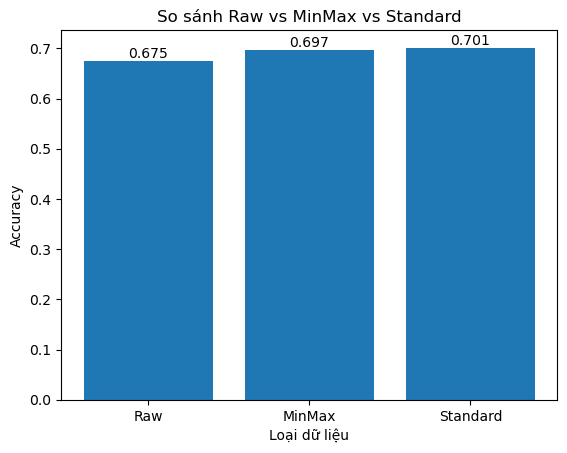

In [94]:
plt.figure()

bars = plt.bar(results["Data Type"], results["Accuracy"])

# Hiển thị giá trị trên cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3),
             ha='center', va='bottom')

plt.xlabel("Loại dữ liệu")
plt.ylabel("Accuracy")
plt.title("So sánh Raw vs MinMax vs Standard")

plt.show()

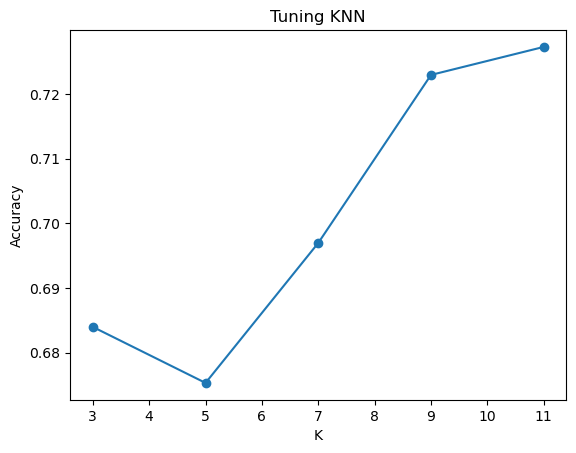

In [96]:
k_values = [3,5,7,9,11]
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    from sklearn.metrics import accuracy_score
    scores.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, scores, marker='o')

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Tuning KNN")

plt.show()

In [97]:
best_k = k_values[np.argmax(scores)]
best_model = KNeighborsClassifier(n_neighbors=best_k)

best_model.fit(X_train_std, y_train)
y_pred = best_model.predict(X_test_std)

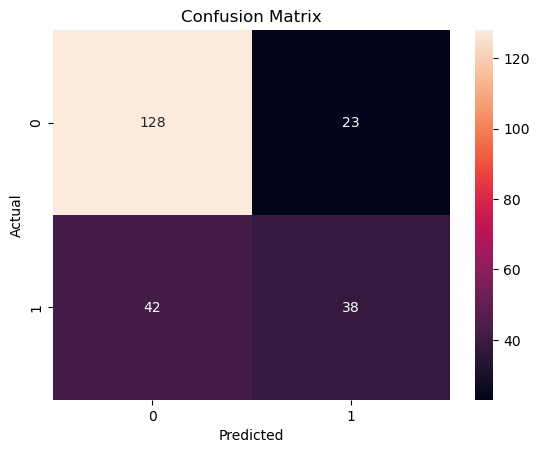

In [98]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [99]:
print("Best K:", best_k)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best K: 11
Accuracy: 0.7186147186147186
              precision    recall  f1-score   support

           0       0.75      0.85      0.80       151
           1       0.62      0.47      0.54        80

    accuracy                           0.72       231
   macro avg       0.69      0.66      0.67       231
weighted avg       0.71      0.72      0.71       231



In [88]:
import joblib

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [89]:
model = joblib.load("best_model.pkl")

In [90]:


results = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_best)
    ]
})

results.to_csv("results.csv", index=False)